# Clasificación — Regresión Logística _(versión detallada)_

_Sigmoide, probabilidades, frontera de decisión y métricas_

**Módulo 1 — Aprendizaje Supervisado** | DSRP Machine Learning Engineering  
**Profesor:** Miguel Arquez

---
> 📖 **Nota:** Esta es la versión detallada del notebook `04_clasificacion_regresion_logistica.ipynb`.  
> Incluye teoría ampliada y comentarios línea a línea en cada bloque de código.

![Aprendizaje Supervisado](assets/header.png)

## 1. ¿Qué es la clasificación?

En aprendizaje supervisado, cuando la variable objetivo $y$ es **categórica** (no continua), el problema se llama **clasificación**.

### Tipos de clasificación
| Tipo | Descripción | Ejemplo |
|------|-------------|--------|
| **Binaria** | $y \in \{0, 1\}$ | ¿El cliente se va o se queda? |
| **Multiclase** | $y \in \{1, \dots, K\}$ | Tipo de producto |
| **Multilabel** | Múltiples etiquetas a la vez | Géneros de una película |

### ¿Por qué no usar regresión lineal directamente?

Supongamos que intentamos predecir $P(y=1|x)$ con regresión lineal: $\hat{y} = \beta_0 + \beta_1 x$.

Problemas:
1. La salida puede ser **mayor que 1 o menor que 0** — imposible para una probabilidad.
2. La relación entre los predictores y la **probabilidad de un evento** raramente es lineal en toda su extensión.
3. Los residuos no siguen una distribución normal, violando supuestos de MCO.

> 📌 **¿Qué son los residuos?**  
> Cuando un modelo hace una predicción $\hat{y}$, el **residuo** es simplemente la diferencia entre lo que el modelo predijo y lo que realmente ocurrió:  
> $$e_i = y_i - \hat{y}_i$$  
> Si predijiste que un cliente pagaría \$100 y pagó \$115, el residuo es $115 - 100 = 15$.  
> El análisis de residuos permite diagnosticar si el modelo se equivoca de forma sistemática.

> 📌 **¿Qué son los supuestos de MCO (Mínimos Cuadrados Ordinarios)?**  
> MCO es el método que usa la **regresión lineal** para estimar los coeficientes $\beta$ (minimiza la suma de residuos al cuadrado). Para que sus resultados sean válidos y confiables, necesita que se cumplan ciertos supuestos sobre los residuos:  
> - Los residuos tienen **media cero** (el modelo no sesga sistemáticamente hacia arriba o abajo).  
> - Los residuos siguen una **distribución normal** (campana de Gauss) — necesario para que los intervalos de confianza y p-valores sean correctos.  
> - La **varianza de los residuos es constante** en todos los valores de $x$ (homocedasticidad).  
> - Los residuos son **independientes** entre observaciones.  
>
> Cuando usamos regresión lineal para clasificar (predecir 0s y 1s), los residuos toman solo dos valores posibles y forman una distribución bimodal — **nada parecida a una normal**. Por eso MCO no es el método correcto para clasificación. La regresión logística no necesita este supuesto porque usa un método diferente (máxima verosimilitud).

La solución es pasar la salida lineal por una función que **aplaste** el resultado al intervalo $(0,1)$: la **sigmoide**.

## 2. La función sigmoide

Para que un modelo lineal entregue probabilidades válidas, pasamos su salida por la **sigmoide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Propiedades importantes

| Propiedad | Valor |
|-----------|-------|
| Rango de salida | $(0, 1)$ — siempre una probabilidad válida |
| $\sigma(0)$ | $0.5$ — punto de inflexión |
| $\sigma(z) \to 1$ cuando $z \to +\infty$ | |
| $\sigma(z) \to 0$ cuando $z \to -\infty$ | |
| Derivada | $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — muy útil para backpropagation |

### Relación con odds y log-odds

Si $p = \sigma(z)$, entonces:

$$\text{odds} = \frac{p}{1-p} = e^z$$

$$\log\left(\frac{p}{1-p}\right) = z = \beta_0 + \beta_1 x_1 + \dots$$

Esto se llama **log-odds** o **logit**. La regresión logística modela el logit como una función lineal de los predictores — de ahí el nombre.

> 💡 **Interpretación de coeficientes:** Un aumento de 1 unidad en $x_i$ multiplica los odds por $e^{\beta_i}$. Si $\beta_i = 0.5$, los odds aumentan un factor de $e^{0.5} \approx 1.65$ (65% más).

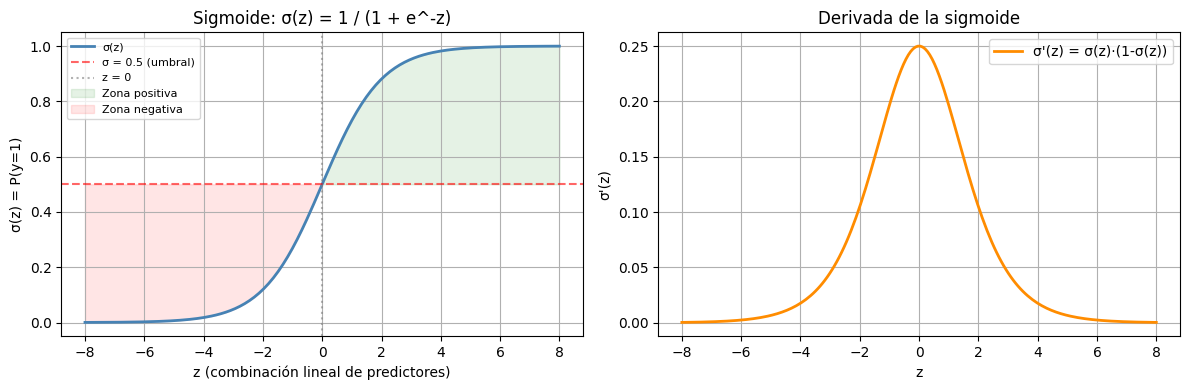

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Creamos 200 puntos equidistantes entre -8 y 8 para graficar la curva suave
z = np.linspace(-8, 8, 200)

# Calculamos la función sigmoide: σ(z) = 1 / (1 + e^(-z))
# np.exp(-z) calcula e^(-z) para cada valor de z
sigma = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Gráfico 1: Sigmoide clásica ---
axes[0].plot(z, sigma, lw=2, color='steelblue', label='σ(z)')
axes[0].axhline(0.5, color='red', ls='--', alpha=0.6, label='σ = 0.5 (umbral)')
axes[0].axvline(0,   color='gray', ls=':',  alpha=0.6, label='z = 0')
axes[0].fill_between(z, sigma, 0.5, where=(sigma > 0.5), alpha=0.1, color='green', label='Zona positiva')
axes[0].fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.1, color='red',   label='Zona negativa')
axes[0].set_title('Sigmoide: σ(z) = 1 / (1 + e^-z)')
axes[0].set_xlabel('z (combinación lineal de predictores)')
axes[0].set_ylabel('σ(z) = P(y=1)')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# --- Gráfico 2: Derivada de la sigmoide ---
# La derivada es σ(z) * (1 - σ(z)) — máxima en z=0, cero en los extremos
deriv = sigma * (1 - sigma)
axes[1].plot(z, deriv, lw=2, color='darkorange', label="σ'(z) = σ(z)·(1-σ(z))")
axes[1].set_title('Derivada de la sigmoide')
axes[1].set_xlabel('z')
axes[1].set_ylabel("σ'(z)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 3. El modelo de regresión logística

Aplicamos la sigmoide a una combinación lineal de los predictores:

$$P(y = 1 \mid x) = \sigma\!\left(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p\right) = \frac{1}{1 + e^{-(\beta_0 + \boldsymbol{\beta}^\top \mathbf{x})}}$$

### ¿Cómo aprende? — Función de pérdida: Log-Loss (Cross-Entropy)

A diferencia de la regresión lineal (que minimiza el MSE), la regresión logística minimiza la **log-loss**:

$$\mathcal{L}(\beta) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Intuición:
- Si $y_i = 1$ y $\hat{p}_i \approx 1$: $\log(1) = 0$ → pérdida pequeña ✅
- Si $y_i = 1$ y $\hat{p}_i \approx 0$: $\log(0) \to -\infty$ → pérdida enorme ❌

### Regularización

`scikit-learn` aplica regularización L2 por defecto (parámetro `C`):

$$\mathcal{L}_{reg}(\beta) = \mathcal{L}(\beta) + \frac{1}{C} \|\beta\|^2$$

- **C grande** → poca regularización, modelo más flexible (riesgo de sobreajuste)
- **C pequeño** → más regularización, coeficientes más pequeños (riesgo de subajuste)

### Supuestos del modelo
1. Los **log-odds** son lineales en los predictores.
2. Las observaciones son **independientes** entre sí.
3. **No hay multicolinealidad** severa entre predictores (aunque la regularización mitiga esto).
4. La muestra es suficientemente grande (regla empírica: ≥10 eventos por predictor).

## 4. Frontera de decisión

Con un umbral $\tau$ (típicamente 0.5), clasificamos:

$$\hat{y} = \begin{cases} 1 & \text{si } \hat{p} \geq \tau \\ 0 & \text{si } \hat{p} < \tau \end{cases}$$

La frontera ocurre cuando $\hat{p} = 0.5$, es decir cuando $z = 0$:
$$\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p = 0$$

Esto es una **línea recta** (o hiperplano en alta dimensión) → regresión logística genera **fronteras lineales**.

### Trade-off al mover el umbral

| Umbral | Efecto | Cuándo usarlo |
|--------|--------|---------------|
| **Bajo (e.g. 0.3)** | ↑ Recall, ↓ Precision | Detectar fraude, diagnóstico médico (caro perder positivos) |
| **Alto (e.g. 0.7)** | ↓ Recall, ↑ Precision | Campañas de marketing (caro contactar falsos positivos) |

> 🎯 La elección del umbral es una **decisión de negocio**, no técnica. La curva ROC permite visualizar todos los umbrales simultáneamente.

## 5. Métricas de clasificación

### Matriz de confusión

|              | Pred. positivo | Pred. negativo |
|---|---|---|
| **Real positivo** | TP (Verdadero Positivo) | FN (Falso Negativo — Error Tipo II) |
| **Real negativo** | FP (Falso Positivo — Error Tipo I) | TN (Verdadero Negativo) |

### Métricas derivadas

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \qquad \text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \qquad F_\beta = (1+\beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

### Guía rápida de cuándo usar cada métrica

| Métrica | Úsala cuando... | Problema con clases desbalanceadas |
|---------|-----------------|------------------------------------|
| **Accuracy** | Clases balanceadas | Sí — engaña mucho |
| **Precision** | FP es muy costoso | No, pero ignora FN |
| **Recall** | FN es muy costoso | No, pero ignora FP |
| **F1** | Balance Precision/Recall | Moderado |
| **ROC-AUC** | Comparar modelos, independiente del umbral | No |
| **PR-AUC** | Clases muy desbalanceadas | No |

### Curva ROC

Grafica **TPR (Recall)** vs **FPR** $= \frac{FP}{FP+TN}$ al variar el umbral:
- **AUC = 1.0**: modelo perfecto
- **AUC = 0.5**: modelo aleatorio (línea diagonal)
- **AUC < 0.5**: modelo que predice al revés

## 6. Caso práctico — Telco Customer Churn (Kaggle)

**Dataset:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
**Archivo:** `WA_Fn-UseC_-Telco-Customer-Churn.csv` (7.043 × 21).

**Estructura.** Cada fila es un cliente. Las 21 columnas se agrupan así:

- **Identificador**: `customerID`.
- **Demografía**: `gender`, `SeniorCitizen` (0/1), `Partner`, `Dependents`.
- **Cuenta**: `tenure` (meses con la compañía), `Contract`, `PaperlessBilling`, `PaymentMethod`.
- **Servicios**: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- **Facturación**: `MonthlyCharges`, `TotalCharges` (viene como string — hay que convertir).
- **Target**: `Churn` (Yes / No) → **desbalance moderado: ≈26.5% churners**.

### ¿Por qué importa el desbalance?

Si el 73.5% de los clientes NO hace churn, un modelo que **siempre predice No-churn** tendría 73.5% de accuracy. Por eso debemos mirar **F1, Recall y ROC-AUC** además del accuracy.

In [2]:
from pathlib import Path
import pandas as pd

# Definimos la ruta al CSV usando pathlib (más robusto que strings de ruta)
DATA = Path('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Verificamos que el archivo existe antes de intentar cargarlo
if not DATA.exists():
    raise FileNotFoundError(
        f'No se encontró {DATA}. Descarga el dataset desde '
        'https://www.kaggle.com/datasets/blastchar/telco-customer-churn '
        'y colócalo en data/ (ver README.md).'
    )

# Cargamos el CSV completo en un DataFrame de pandas
df = pd.read_csv(DATA)

# TotalCharges viene como string con espacios en blanco para clientes muy nuevos
# errors='coerce' convierte esos strings inválidos a NaN en lugar de lanzar un error
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Eliminamos las filas con NaN en TotalCharges (clientes con tenure=0, sin cobro aún)
# reset_index reestablece el índice después de dropear filas
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

# Codificamos la variable objetivo: 'Yes' → 1 (churn), 'No' → 0 (no churn)
# astype(int) convierte el booleano resultante a 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Mostramos forma y tasa de churn para verificar la carga
print('Shape:', df.shape, '| Tasa de churn:', round(df.Churn.mean(), 3))
df.head()


Shape: (7032, 21) | Tasa de churn: 0.266


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### Preprocesamiento: feature engineering

La regresión logística requiere que **todas las entradas sean numéricas**. Para las variables categóricas usamos **One-Hot Encoding** (también llamado *dummy coding*):

- Se crea una columna binaria (0/1) por cada categoría.
- `drop_first=True` elimina la primera categoría para evitar la **trampa de la variable dummy** (multicolinealidad perfecta). La categoría eliminada queda como referencia implícita.

#### ¿Por qué escalar?

La regresión logística usa gradiente descendiente internamente. Si `tenure` está en rango [0,72] y `SeniorCitizen` en [0,1], el gradiente de `tenure` domina. La **estandarización** ($z = \frac{x - \mu}{\sigma}$) pone todo en la misma escala:
- **IMPORTANTE:** ajustar el scaler **solo con train**, aplicarlo a test. Nunca al revés (data leakage).

In [3]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
)

# Estilo visual para todos los gráficos
sns.set_theme(style='whitegrid')

# Columnas numéricas: se usan tal cual (solo se estandarizarán después)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Columnas categóricas: se convertirán a dummies (One-Hot Encoding)
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
            'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# pd.get_dummies aplica One-Hot Encoding solo a las columnas en 'columns='
# drop_first=True elimina la primera categoría de cada variable (referencia)
# para evitar multicolinealidad perfecta entre las dummies
X = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True)

# Variable objetivo
y = df['Churn']

print('Shape de X:', X.shape)  # 4 numéricas + dummies de las categóricas
X


Shape de X: (7032, 16)


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,True,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,True,False,False,True,False,False,False,False,True
2,2,53.85,108.15,0,True,False,False,True,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,0,False,False,False,True,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,24,84.80,1990.50,0,True,True,True,True,False,False,True,False,True,False,False,True
7028,72,103.20,7362.90,0,False,True,True,True,True,False,True,False,True,True,False,False
7029,11,29.60,346.45,0,False,True,True,False,False,False,False,False,True,False,True,False
7030,4,74.40,306.60,1,True,True,False,True,True,False,False,False,True,False,False,True


In [4]:
# Dividimos en train (80%) y test (20%)
# stratify=y asegura que la proporción de churners sea igual en train y test
# (crucial con clases desbalanceadas para que el test sea representativo)
# random_state=42 para reproducibilidad
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarización: fit() calcula media y desviación estándar SOLO del train
# Esto evita data leakage: el test simula datos futuros que no conocemos
scaler = StandardScaler().fit(X_tr)

# transform() aplica la transformación z = (x - mean) / std
# Usamos los parámetros del train para transformar AMBOS conjuntos
X_tr_s = scaler.transform(X_tr)   # train estandarizado
X_te_s = scaler.transform(X_te)   # test estandarizado con parámetros del TRAIN

# Entrenamos la regresión logística
# max_iter=1000: número máximo de iteraciones del solver (LBFGS por defecto)
# C=1.0 (default): regularización L2 moderada
logit = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)

# Extraemos y ordenamos los coeficientes por magnitud absoluta
# Los coeficientes son comparables entre sí porque estandarizamos
coefs = pd.DataFrame({
    'feature': X.columns,
    'beta': logit.coef_[0],  # coef_ tiene shape (1, n_features) para clasificación binaria
}).sort_values('beta', key=abs, ascending=False).head(12)
coefs


,feature,beta
0,tenure,-1.342939
11,Contract_Two year,-0.685092
2,TotalCharges,0.613475
8,InternetService_Fiber optic,0.417587
10,Contract_One year,-0.345990
7,PhoneService_Yes,-0.221547
14,PaymentMethod_Electronic check,0.213153
12,PaperlessBilling_Yes,0.169158
1,MonthlyCharges,0.167421
9,InternetService_No,-0.151308


### Interpretación de coeficientes

Como estandarizamos los predictores, los coeficientes $\beta$ son **directamente comparables** en magnitud:

| Signo de $\beta$ | Interpretación |
|-----------------|----------------|
| **Positivo** | La variable **aumenta** la probabilidad de churn |
| **Negativo** | La variable **disminuye** la probabilidad de churn |

#### Análisis de los top coeficientes:

- **`tenure` ($\beta \approx -1.34$)**: El predictor más fuerte. Clientes con más antigüedad son mucho menos propensos a irse. Esto tiene sentido: clientes leales ya se "engancharon".
- **`Contract_Two year` ($\beta \approx -0.69$)**: Contratos largos retienen clientes.
- **`TotalCharges` ($\beta \approx +0.61$)**: Positivo, pero está muy correlacionado con `tenure` (mayor tiempo → más cargos acumulados). Este coeficiente captura información residual.
- **`InternetService_Fiber optic` ($\beta \approx +0.42$)**: Fibra óptica se asocia con más churn (¿tarifa más alta? ¿más competencia en ese segmento?).

> ⚠️ **Multicolinealidad:** `tenure` y `TotalCharges` están altamente correlacionados. Los coeficientes individuales pueden ser difíciles de interpretar cuando hay colinealidad — pero la **predicción del modelo** sigue siendo válida.

In [5]:
# predict() aplica el umbral 0.5 internamente y devuelve 0 o 1
y_pred = logit.predict(X_te_s)

# predict_proba() devuelve probabilidades para CADA clase
# [:, 1] selecciona la columna 1 = P(Churn=1)
# [:, 0] sería P(Churn=0) = 1 - P(Churn=1)
y_proba = logit.predict_proba(X_te_s)[:, 1]

# Calculamos las métricas principales
print(f'Accuracy  : {accuracy_score(y_te, y_pred):.3f}')          # fracción total correcta
print(f'Precision : {precision_score(y_te, y_pred):.3f}')         # TP / (TP + FP)
print(f'Recall    : {recall_score(y_te, y_pred):.3f}')            # TP / (TP + FN)
print(f'F1        : {f1_score(y_te, y_pred):.3f}')                # media armónica P y R
print(f'ROC AUC   : {roc_auc_score(y_te, y_proba):.3f}')          # área bajo curva ROC

# classification_report muestra todas las métricas por clase en una tabla
# target_names nos permite poner etiquetas legibles en lugar de 0/1
print('\n', classification_report(y_te, y_pred, target_names=['No churn', 'Churn']))


Accuracy  : 0.803
Precision : 0.650
Recall    : 0.561
F1        : 0.603
ROC AUC   : 0.835

               precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1033
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



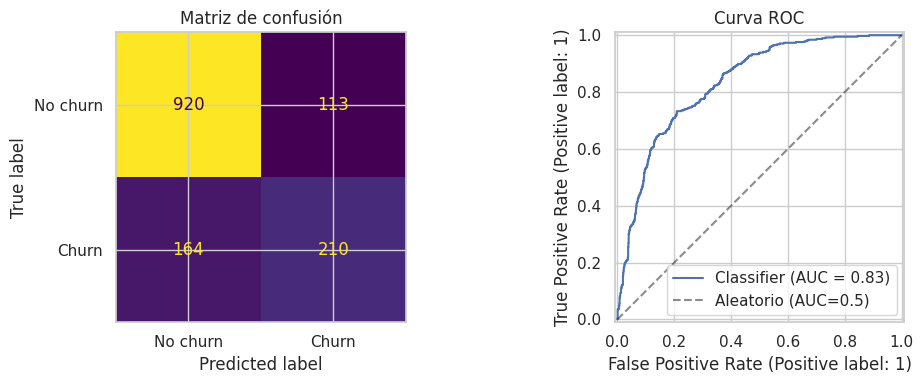

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Matriz de confusión ---
# confusion_matrix(y_real, y_pred) devuelve una matriz 2x2:
# [[TN, FP],
#  [FN, TP]]
# ConfusionMatrixDisplay la convierte en un heatmap con etiquetas
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred),
    display_labels=['No churn', 'Churn'],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión')

# --- Curva ROC ---
# from_predictions() calcula la curva variando el umbral de 0 a 1
# Cada punto de la curva es (FPR, TPR) para un umbral distinto
# Queremos estar en la esquina superior izquierda (TPR=1, FPR=0)
RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1])

# Línea diagonal = clasificador aleatorio (AUC=0.5)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio (AUC=0.5)')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Visualizamos cómo se distribuyen las probabilidades predichas para cada clase real
# Un buen modelo debería mostrar poca superposición entre las dos distribuciones
fig, ax = plt.subplots(figsize=(7, 4))

for label, name, color in [(0, 'No churn', 'steelblue'), (1, 'Churn', 'tomato')]:
    # Filtramos las probabilidades para los clientes de cada clase real
    # y_te == label crea una máscara booleana para seleccionar las probabilidades
    ax.hist(y_proba[y_te == label], bins=30, alpha=0.6, label=name, color=color)

# Umbral de clasificación: arriba → Churn, abajo → No churn
ax.axvline(0.5, color='red', ls='--', label='Umbral 0.5')

# Zonas de clasificación
ax.axvspan(0.5, 1.0, alpha=0.05, color='tomato')       # zona predicha como Churn
ax.axvspan(0.0, 0.5, alpha=0.05, color='steelblue')    # zona predicha como No churn

ax.set_xlabel('P(churn) predicha')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de probabilidades predichas por clase real')
ax.legend()
plt.show()

# INTERPRETACIÓN:
# - Los clientes "No churn" deberían concentrarse cerca de 0
# - Los clientes "Churn" deberían concentrarse cerca de 1
# - La superposición en el centro representa los casos ambiguos (difíciles de clasificar)


## 7. Referencias

- ISLR cap. 4: *Classification*.
- Hosmer, Lemeshow & Sturdivant (2013). *Applied Logistic Regression*.
- scikit-learn user guide: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## 8. Predicción sobre datos nuevos — uso del modelo en producción

Una vez validado el modelo en test, el flujo de producción sigue **tres pasos críticos**:

### Paso 1 — Reentrenar con todos los datos
Ya validamos el rendimiento con train/test. Ahora usamos el **100% de los datos** para el modelo final:
- El modelo tiene más información → mejores estimaciones de $\beta$.
- Ya no necesitamos el test set (ya cumplió su función de validación).

### Paso 2 — Reproducir el preprocesamiento exacto
El error más común en producción: aplicar transformaciones diferentes a los datos nuevos.
- Mismo orden de columnas
- Mismo encoding (mismas categorías de referencia)
- Misma escala (parámetros del scaler ajustado en train)

### Paso 3 — Persistir el modelo con `joblib`
Guardar modelo + scaler + metadata en un único bundle para:
- Evitar reentrenar cada vez
- Garantizar que el preprocesamiento siempre sea el correcto
- Facilitar el versionado del modelo

In [9]:
import joblib

# Reentrenamos el scaler sobre TODOS los datos disponibles (train + test)
# Ahora sí podemos usar todo X porque ya terminamos la validación
scaler_final = StandardScaler().fit(X)

# Entrenamos el modelo final con todos los datos estandarizados
modelo_final = LogisticRegression(max_iter=1000).fit(scaler_final.transform(X), y)

# Creamos un bundle (diccionario) con todo lo necesario para hacer predicciones
# sin depender del entorno de entrenamiento
bundle = {
    'modelo':    modelo_final,          # el modelo entrenado
    'scaler':    scaler_final,          # el scaler (media y std de cada feature)
    'columnas':  X.columns.tolist(),    # orden exacto de columnas que espera el modelo
    'num_cols':  num_cols,              # columnas numéricas originales
    'cat_cols':  cat_cols,              # columnas categóricas originales
}

# joblib.dump serializa el objeto Python a disco (más eficiente que pickle para arrays)
joblib.dump(bundle, 'modelo_telco_logit.pkl')
print('Bundle guardado.')


Bundle guardado.


### Inferencia individual — un cliente nuevo

#### El problema de alineación de columnas

Cuando aplicamos `pd.get_dummies` a un **solo cliente**, las columnas resultantes pueden diferir de las del entrenamiento:

- Si el cliente tiene `Contract='Month-to-month'`, no aparecerán `Contract_One year` ni `Contract_Two year` → **faltan columnas**.
- Si tuviéramos nuevas categorías no vistas en train → **sobran columnas**.

**Solución:** `reindex(columns=X.columns, fill_value=0)`
- Añade las columnas faltantes con valor 0 (equivale a "esa categoría no aplica")
- Descarta columnas extra desconocidas por el modelo

> 💡 En producción con más volumen, usar `sklearn.pipeline.Pipeline` + `OneHotEncoder` es más robusto que `pd.get_dummies`.

In [8]:
# Definimos un cliente hipotético con todas sus características
# (en producción esto vendría de una API, base de datos, etc.)
nuevo_cliente_raw = pd.DataFrame([{
    'tenure':            5,              # solo 5 meses con la compañía (cliente nuevo)
    'MonthlyCharges':    85.0,           # tarifa mensual alta
    'TotalCharges':      425.0,          # 5 meses × $85 ≈ $425
    'SeniorCitizen':     0,              # no es adulto mayor
    'gender':            'Female',
    'Partner':           'No',
    'Dependents':        'No',
    'PhoneService':      'Yes',
    'InternetService':   'Fiber optic',  # fibra óptica (coef positivo = más riesgo)
    'Contract':          'Month-to-month',  # sin compromiso de largo plazo (más riesgo)
    'PaperlessBilling':  'Yes',
    'PaymentMethod':     'Electronic check',  # coef positivo = más riesgo
}])

# Aplicamos el mismo One-Hot Encoding que en entrenamiento
nuevo = pd.get_dummies(nuevo_cliente_raw, columns=cat_cols, drop_first=True)

# Alineamos columnas: añadimos las que faltan (=0) y eliminamos las extra
# Esto garantiza que el modelo recibe exactamente las features que espera
nuevo = nuevo.reindex(columns=X.columns, fill_value=0)

# Aplicamos la misma estandarización del entrenamiento
prob = modelo_final.predict_proba(scaler_final.transform(nuevo))[0, 1]

print(f'P(churn) = {prob:.3f}')
print(f'Predicción @ umbral 0.5: {"Churn" if prob >= 0.5 else "No churn"}')
print(f'Predicción @ umbral 0.3: {"Churn" if prob >= 0.3 else "No churn"}  '
      f'(más conservador, mayor recall)')


P(churn) = 0.499
Predicción @ umbral 0.5: No churn
Predicción @ umbral 0.3: Churn  (más conservador, mayor recall)


### Caso de uso: ranking de clientes por riesgo

En la práctica, rara vez interesa la clasificación binaria pura. Lo más valioso es **ordenar a los clientes por probabilidad de churn** para priorizar acciones:

#### Estrategia de retención basada en riesgo

```
P(churn) > 0.8  → Llamada directa + descuento personalizado
P(churn) > 0.6  → Email con oferta de upgrade
P(churn) > 0.4  → Encuesta de satisfacción
P(churn) < 0.4  → Sin acción proactiva
```

Este enfoque permite **optimizar el ROI de las campañas de retención** concentrando el presupuesto en los clientes de mayor riesgo.

In [ ]:
# Predecimos probabilidades para todo el conjunto de test
test_proba = modelo_final.predict_proba(scaler_final.transform(X_te))[:, 1]

# Creamos un DataFrame combinando probabilidad predicha y etiqueta real
ranking = (
    pd.DataFrame({
        'P_churn':     test_proba.round(3),  # probabilidad de churn (0-1)
        'churn_real':  y_te.values,          # etiqueta real (ground truth)
    })
    .sort_values('P_churn', ascending=False)  # ordenamos de mayor a menor riesgo
    .head(10)                                 # top 10 clientes más riesgosos
    .reset_index(drop=True)                   # reindexamos de 0 a 9
)

print('Top 10 clientes con mayor probabilidad de churn (test set):')
# churn_real=1 significa que SÍ hizo churn → el modelo los identificó correctamente
# churn_real=0 en este top sería un falso positivo
ranking


## 9. Lecciones clave para producción

### ✅ Lo que siempre debes hacer

1. **Guardar el `scaler` junto al modelo**: predecir sin estandarizar rompe la regresión logística silenciosamente (sin error, con predicciones incorrectas).

2. **Versionar el bundle completo**: modelo + scaler + lista de columnas + nombres de features.

3. **Monitorear la calibración**: las probabilidades deben reflejar frecuencias reales. Si el modelo dice 80% de churn para 100 clientes, ~80 deben haber hecho churn. Usa `calibration_curve` de sklearn.

4. **Revisar el umbral**: el 0.5 es un default, no una decisión de negocio. Calcula el costo de FP vs FN para tu caso específico.

### ⚠️ Errores comunes

| Error | Consecuencia |
|-------|-------------|
| Fitear el scaler con train+test | Data leakage — métricas irrealistamente buenas |
| No alinear columnas en producción | Predicciones completamente incorrectas |
| Usar accuracy con clases desbalanceadas | Modelo aparentemente bueno que falla en la clase minoritaria |
| No monitorear en el tiempo | Model drift — el modelo se degrada sin que nadie lo note |

## 10. Carga del modelo desde disco — flujo real de producción

En el ejemplo anterior todo estaba **en memoria** (mismo notebook). En producción el escenario es diferente:

- El modelo se entrenó en un job separado (o en otro servidor) y se guardó como `.pkl`.
- El servicio de inferencia (una API, un script batch, un container) **solo tiene el `.pkl`** — no tiene acceso a los datos de entrenamiento ni a las variables del notebook.

### Flujo real en producción

```
[Entrenamiento]          [Producción / inferencia]
  train.py  ──pkl──►  api.py / batch_job.py / container
                           │
                           1. joblib.load('modelo.pkl')
                           2. recibir datos crudos (JSON, CSV, DB)
                           3. one-hot encode igual que en train
                           4. reindex con las columnas guardadas en el bundle
                           5. scaler.transform(X_nuevo)
                           6. modelo.predict_proba(X_scaled)
                           7. retornar probabilidad / clasificación
```

> 🔑 **La clave:** el bundle contiene `columnas`, `num_cols` y `cat_cols` — toda la metadata necesaria para reproducir el preprocesamiento **sin depender del código de entrenamiento**.

In [ ]:
import joblib
import pandas as pd

# ─────────────────────────────────────────────────────────────────
# PASO 1: Cargar el bundle desde disco
# Esto es lo ÚNICO que necesitas en producción — sin datos de train,
# sin variables previas del notebook, sin imports de sklearn adicionales.
# ─────────────────────────────────────────────────────────────────
bundle = joblib.load('modelo_telco_logit.pkl')

# Extraemos cada pieza del bundle
modelo   = bundle['modelo']    # LogisticRegression ya entrenado
scaler   = bundle['scaler']    # StandardScaler con media/std del entrenamiento
columnas = bundle['columnas']  # lista de features que espera el modelo (orden exacto)
cat_cols = bundle['cat_cols']  # columnas que necesitan one-hot encoding

print('Modelo cargado:', type(modelo).__name__)
print('Features esperadas:', len(columnas))
print(columnas)

# ─────────────────────────────────────────────────────────────────
# PASO 2: Recibir datos crudos (simulamos datos entrantes)
# En producción esto vendría de una API (JSON), base de datos, Kafka, etc.
# ─────────────────────────────────────────────────────────────────
datos_crudos = pd.DataFrame([{
    'tenure':            2,
    'MonthlyCharges':    90.0,
    'TotalCharges':      180.0,
    'SeniorCitizen':     1,
    'gender':            'Male',
    'Partner':           'No',
    'Dependents':        'No',
    'PhoneService':      'Yes',
    'InternetService':   'Fiber optic',
    'Contract':          'Month-to-month',
    'PaperlessBilling':  'Yes',
    'PaymentMethod':     'Electronic check',
}])

# ─────────────────────────────────────────────────────────────────
# PASO 3: Preprocesamiento — debe ser IDÉNTICO al que se hizo en entrenamiento
# Usamos drop_first=True igual que en train (si no, las columnas no coinciden)
# ─────────────────────────────────────────────────────────────────
X_nuevo = pd.get_dummies(datos_crudos, columns=cat_cols, drop_first=True)

# ─────────────────────────────────────────────────────────────────
# PASO 4: Alinear columnas con las del entrenamiento
# - Si al cliente le falta alguna columna (ej: nunca tuvo "Contract_Two year")
#   reindex la añade con 0 (esa categoría no aplica).
# - Si hubiera categorías nuevas no vistas en train, reindex las descarta.
# Esto es lo que hace el modelo robusto ante variaciones en datos nuevos.
# ─────────────────────────────────────────────────────────────────
X_nuevo = X_nuevo.reindex(columns=columnas, fill_value=0)

# ─────────────────────────────────────────────────────────────────
# PASO 5: Estandarizar con los parámetros del entrenamiento
# NUNCA volvemos a llamar fit() aquí — solo transform()
# Los parámetros (media y std) ya están guardados dentro de `scaler`
# ─────────────────────────────────────────────────────────────────
X_scaled = scaler.transform(X_nuevo)

# ─────────────────────────────────────────────────────────────────
# PASO 6: Inferencia
# predict_proba devuelve [[P(no_churn), P(churn)]]
# [:, 1] selecciona P(churn) para todas las filas
# ─────────────────────────────────────────────────────────────────
probabilidad = modelo.predict_proba(X_scaled)[0, 1]
prediccion   = modelo.predict(X_scaled)[0]

print(f'\nP(churn)      = {probabilidad:.3f}')
print(f'Clasificación = {"Churn" if prediccion == 1 else "No churn"} (umbral 0.5)')

# ─────────────────────────────────────────────────────────────────
# BONUS: cómo se vería esto en producción (pseudo-código de una API FastAPI)
# ─────────────────────────────────────────────────────────────────
print("""
─── Ejemplo en una API real (FastAPI) ───────────────────────────

from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
bundle = joblib.load("modelo_telco_logit.pkl")  # carga UNA vez al iniciar

@app.post("/predict")
def predict(cliente: dict):
    df = pd.DataFrame([cliente])
    X  = pd.get_dummies(df, columns=bundle["cat_cols"], drop_first=True)
    X  = X.reindex(columns=bundle["columnas"], fill_value=0)
    X  = bundle["scaler"].transform(X)
    prob = bundle["modelo"].predict_proba(X)[0, 1]
    return {"p_churn": round(float(prob), 4)}

──────────────────────────────────────────────────────────────────
""")
